In [14]:
import imageio.v3 as imageio
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tifffile
%config InlineBackend.figure_format = 'svg'

In [15]:
def encode_decimate(a):
    return (a // 256).astype(np.uint8)
def decode_decimate(a):
    return (a * 256).astype(np.uint16)
def roundtrip_decimate(a):
    return decode_decimate(encode_decimate(a))
def roundtrip_jpeg_decimate(a):
    c = imageio.imwrite('<bytes>', encode_decimate(a), extension='.jpg')
    return decode_decimate(imageio.imread(c))

def encode_cuberoot(a):
    return np.clip(np.round((a / 65536.0) ** (1/3) * 256), 0, 255).astype(np.uint8)
def decode_cuberoot(a):
    return np.clip(np.round((a / 256.0) ** 3 * 65536), 0, 65535).astype(np.uint16)
def roundtrip_cuberoot(a):
    return decode_cuberoot(encode_cuberoot(a))
def roundtrip_jpeg_cuberoot(a):
    c = imageio.imwrite('<bytes>', encode_cuberoot(a), extension='.jpg')
    return decode_cuberoot(imageio.imread(c))

def encode_log(a):
    return np.clip(np.round(np.log(a + 1.0) / np.log(65536 + 1) * 256), 0, 255).astype(np.uint8)
def decode_log(a):
    return np.clip(np.round(np.exp(a / 256.0 * np.log(65536 + 1)) - 1), 0, 65535).astype(np.uint16)
def roundtrip_log(a):
    return decode_log(encode_log(a))
def roundtrip_jpeg_log(a):
    c = imageio.imwrite('<bytes>', encode_log(a), extension='.jpg')
    return decode_log(imageio.imread(c))

def roundtrip_noop(a):
    return a

In [3]:
irange = np.arange(0, 65536).astype(np.uint16)

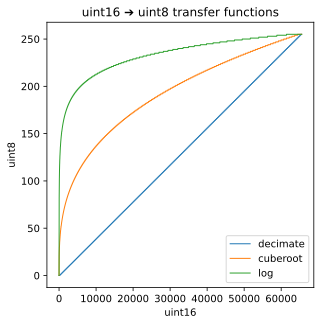

In [4]:
fig, ax = plt.subplots()
ax.plot(encode_decimate(irange), lw=1, label='decimate')
ax.plot(encode_cuberoot(irange), lw=1, label='cuberoot')
ax.plot(encode_log(irange), lw=1, label='log')
ax.set_aspect(256)
ax.legend()
ax.set_xlabel('uint16')
ax.set_ylabel('uint8')
ax.set_title('uint16 ➔ uint8 transfer functions');

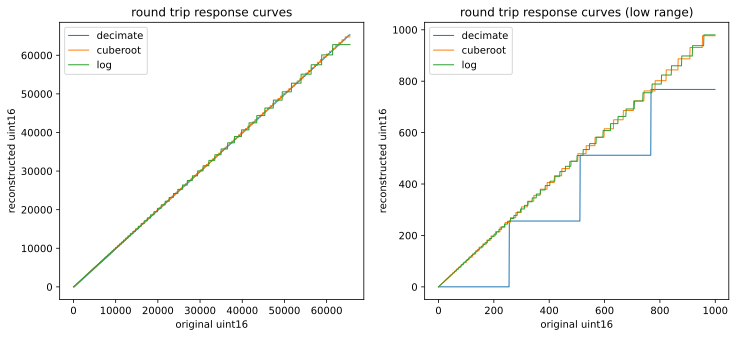

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
xmaxs = [65536, 1000]
exts = ['', ' (low range)']
for ax, xmax, title_ext in zip(axs, xmaxs, exts):
    ax.plot(roundtrip_decimate(irange[:xmax]), lw=1, label='decimate')
    ax.plot(roundtrip_cuberoot(irange[:xmax]), lw=1, label='cuberoot')
    ax.plot(roundtrip_log(irange[:xmax]), lw=1, label='log')
    ax.legend()
    ax.set_xlabel('original uint16')
    ax.set_ylabel('reconstructed uint16')
    ax.set_title('round trip response curves' + title_ext);

In [6]:
def compute_re(i, d):
    with np.errstate(divide='ignore', invalid='ignore'):
        return i.astype(float) / d

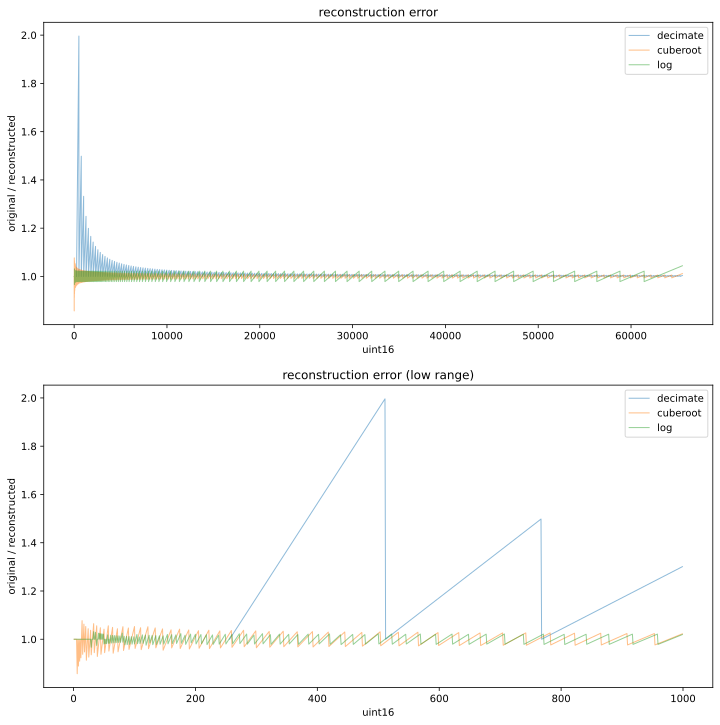

In [8]:
fig, axs = plt.subplots(2, 1, figsize=(12, 12))
xmaxs = [65535, 1000]
exts = ['', ' (low range)']
for ax, xmax, title_ext in zip(axs, xmaxs, exts):
    ax.plot(compute_re(irange[:xmax], roundtrip_decimate(irange[:xmax])), lw=1, alpha=0.5, label='decimate')
    ax.plot(compute_re(irange[:xmax], roundtrip_cuberoot(irange[:xmax])), lw=1, alpha=0.5, label='cuberoot')
    ax.plot(compute_re(irange[:xmax], roundtrip_log(irange[:xmax])), lw=1, alpha=0.5, label='log')
    ax.legend()
    ax.set_xlabel('uint16')
    ax.set_ylabel('original / reconstructed')
    ax.set_title('reconstruction error' + title_ext)

In [9]:
# Demo image available here:
# https://raw.githubusercontent.com/nf-core/test-datasets/refs/heads/modules/data/imaging/segmentation/cycif_tonsil_registered.ome.tif
img = tifffile.imread('cycif_tonsil_registered.ome.tif')

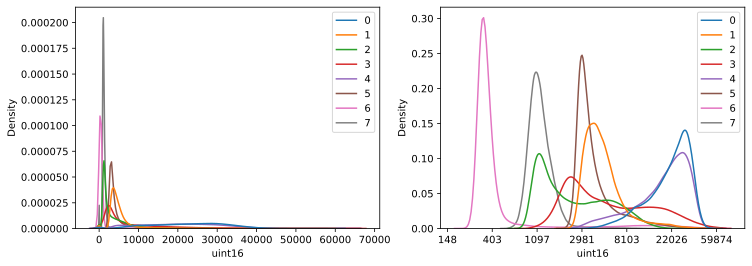

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
img_flat = img.reshape(img.shape[0], -1).T
sns.kdeplot(img_flat, ax=ax1)
with np.errstate(divide='ignore'):
    sns.kdeplot(np.log(img_flat), ax=ax2)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{int(round(np.exp(x)))}"))
plt.setp([ax1, ax2], xlabel='uint16');

In [11]:
icrop = img[7, 0:200, 200:400]

Text(0.5, 0.98, 'image reconstruction (no compression)')

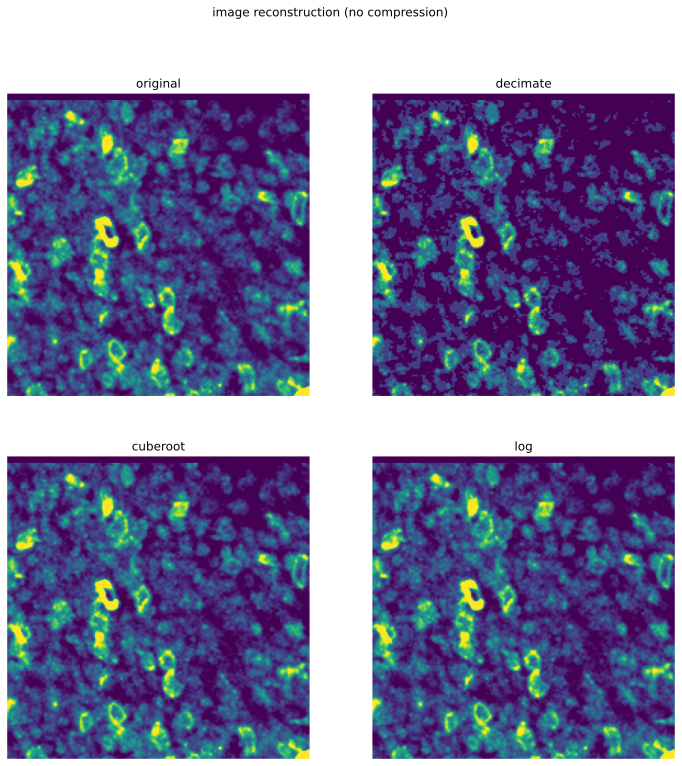

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
fns = [roundtrip_noop, roundtrip_decimate, roundtrip_cuberoot, roundtrip_log]
labels = ['original', 'decimate', 'cuberoot', 'log']
for ax, fn, label in zip(axs.ravel(), fns, labels):
    ax.imshow(fn(icrop), vmin=800, vmax=2000)
    ax.set_title(label)
    ax.set_axis_off()
fig.suptitle('image reconstruction (no compression)')

Text(0.5, 0.98, 'image reconstruction (jpeg compression)')

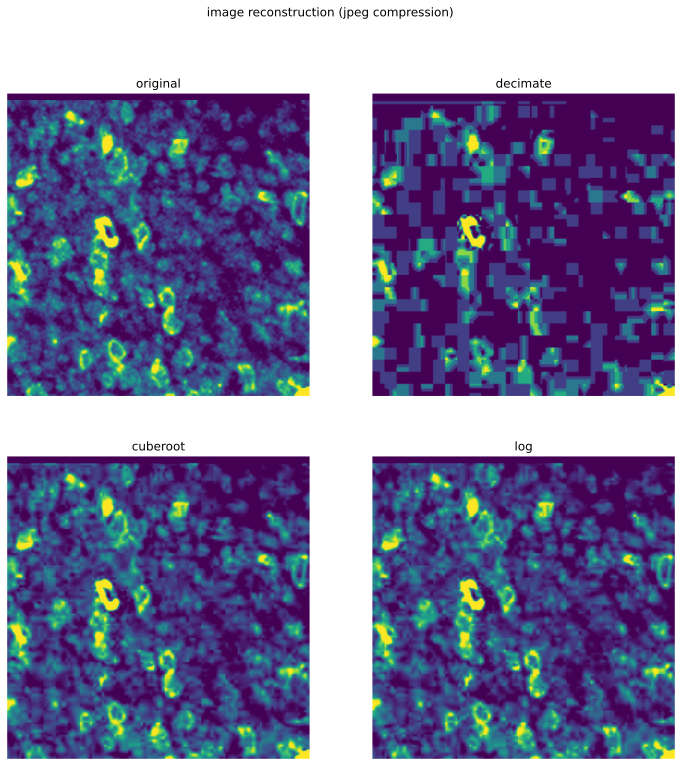

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
fns = [roundtrip_noop, roundtrip_jpeg_decimate, roundtrip_jpeg_cuberoot, roundtrip_jpeg_log]
labels = ['original', 'decimate', 'cuberoot', 'log']
for ax, fn, label in zip(axs.ravel(), fns, labels):
    ax.imshow(fn(icrop), vmin=800, vmax=2000)
    ax.set_title(label)
    ax.set_axis_off()
fig.suptitle('image reconstruction (jpeg compression)')